In [1]:
import matplotlib.pyplot as plt
# from datasets import load_dataset_builder, get_dataset_split_names, load_dataset, Dataset, load_from_disk
from collections import defaultdict
import torchvision
import torchvision.datasets as datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split
from sklearn.utils import shuffle
from sklearn.metrics import f1_score, roc_auc_score
import random
import pickle
import sys
import os
import argparse

import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
module_path = './projects/ModelPrivacy'
if module_path not in sys.path:
    sys.path.append(module_path)

# from util import *
from ModelPrivacy import *
from datetime import datetime

%load_ext autoreload
%autoreload 2

In [2]:
class BaseClassifier(nn.Module):
    def __init__(self, cat):
        super(BaseClassifier, self).__init__()
        self.cat = cat

    def forward(self, x):
        prob = torch.rand(x.shape[0], self.cat)
        prob = prob/(prob.sum(dim=1)[:, None])
        return prob


def score(clf, x, y_true, device='cpu'):
    y_pred = clf(x.to(device)).detach().cpu().squeeze()
    y_true = y_true.argmax(dim=1) if y_true.ndim > 1 else y_true
    acc = 1-zero_one_loss(y_pred, y_true).item()
    f1 = f1_score(y_true, y_pred.argmax(dim=1) if y_pred.ndim > 1 else y_pred, average='weighted')
    auc = roc_auc_score(y_true, y_pred, average='weighted', multi_class='ovr')
    return acc, f1, auc


In [3]:
path = '~/projects'
teacher_dataset_name = 'FashionMNIST'  # hate_speech_offensive
transform = torchvision.transforms.Compose([
torchvision.transforms.Resize((32, 32)),
torchvision.transforms.ToTensor()])
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'

df = pd.DataFrame(columns=['query dataset', 'query size', 'defense', 'un', 'acc', 'f1', 'auc', 'train size'])
i = 0

query_dataset_name = 'MNIST'
teacher_model_name = 'LeNet'  # 'bert-base-uncased'
attacker_model_name = 'LeNet'  #
batch_size = 256

model_path = './saved_models'
teacher_filename = f'fmnist_teacher'
teacher_model_path = f"{model_path}/{teacher_filename}.pt"
attacker_filename = f''

data_teacher_train = datasets.FashionMNIST(root=f'{path}/Datasets', train=True, download=False,
                                           transform=transform)
data_teacher_test = datasets.FashionMNIST(root=f'{path}/Datasets', train=False, download=False,
                                          transform=transform)
data_attacker = eval(
    f"datasets.{query_dataset_name}(root=f'{path}/Datasets', train=True, download=False, transform=transform)")

X_atk_test = np.vstack([x[0].numpy()[None, :] for x in data_teacher_test])
X = np.vstack([x[0].numpy()[None, :] for x in data_teacher_train])
X_attacker = np.vstack([x[0].numpy()[None, :] for x in data_attacker])
X_teacher = X_attacker
y = data_teacher_train.targets.numpy()

X_test = torch.tensor(X_atk_test)
# y_test = data_teacher_test.targets

n_tot = len(y)
train_size = int(0.7 * n_tot)
val_size = int(0.3 * n_tot)

ind = shuffle(list(range(n_tot)))
train_ind = ind[:train_size]
val_ind = ind[train_size:]

train_dataset = TensorDataset(torch.tensor(X[train_ind]), torch.tensor(y[train_ind]))
val_dataset = TensorDataset(torch.tensor(X[val_ind]), torch.tensor(y[val_ind]))
# test_dataset = TensorDataset(torch.tensor(X[test_ind]), torch.tensor(y[test_ind]))
atk_test_dataset = data_teacher_test

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

atk_test_loader = DataLoader(atk_test_dataset, batch_size=batch_size, shuffle=False)
test_loader = atk_test_loader
test_crit = zero_one_loss

# Load teacher
teacher = LeNet5(10).to(device)
teacher.load_state_dict(torch.load(teacher_model_path, map_location=device))
# logger.info(f'Teacher test error: {test(teacher, test_loader, device=device, criterion=test_crit):.4f}')
y_test = teacher(X_test.to(device)).detach().cpu().squeeze()
y_val = teacher((val_dataset.tensors[0][:3000]).to(device)).detach().cpu().squeeze()

res = score(BaseClassifier(10), X_test, y_test, device=device)
res

(0.10360002517700195, 0.10345457738220296, 0.5057257404427875)

In [4]:
import scienceplots
plt.style.use(['science','no-latex'])
# palette = sns.color_palette("tab10", len(defenses))

In [5]:
y_test = teacher(X_test.to(device)).detach().cpu().squeeze()
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
def score(clf, x, y_true, device='cpu'):
    y_pred = clf(x.to(device)).detach().cpu().squeeze()
    # acc = 1-zero_one_loss(y_pred, y_true).item()
    # f1 = f1_score(y_true, y_pred.argmax(dim=1) if y_pred.ndim > 1 else y_pred, average='weighted')
    # auc = roc_auc_score(y_true, y_pred, average='weighted', multi_class='ovr')
    # return acc, f1, auc
    
    acc = zero_one_loss(y_pred, y_true).item()
    ce = CELoss(y_pred, y_true).item()
    return acc, ce

In [9]:
score(teacher, X_test, y_test, device=device)

(0.0, 1.7298605603510708e-10)

In [7]:
df = pd.read_csv('../ModelPrivacy/saved_models/steal_FashionMNIST_LeNet_mp.csv')
df = df.loc[df['defense'] != 'Any',:]
df

,query dataset,query size,defense,un,un_ce,acc,mp_ce,train size
1,FashionMNIST,1000,No,0.000000,0.000000,0.1464,0.276097,1000
2,FashionMNIST,1000,IID,0.010000,0.082361,0.1555,0.296020,1000
3,FashionMNIST,1000,IID,0.020000,0.143737,0.1581,0.298171,1000
4,FashionMNIST,1000,IID,0.050000,0.399508,0.1616,0.318132,1000
5,FashionMNIST,1000,IID,0.100000,0.770923,0.1682,0.393135,1000
...,...,...,...,...,...,...,...,...
1257,MNIST,5000,Const,0.007000,0.007848,0.4337,1.103706,5000
1258,MNIST,5000,Const,0.027333,0.065281,0.4965,1.275006,5000
1259,MNIST,5000,Const,0.041667,0.108642,0.6102,2.196701,5000
1260,MNIST,5000,Const,0.066000,0.174075,0.6727,2.129364,5000


In [8]:
res = score(BaseClassifier(10), X_test, y_test, device=device)

In [12]:
res

(0.8981999754905701, 2.4069149494171143)

In [16]:
t_res = score(teacher, X_test, y_test, device=device)
t_res

(0.0, 1.7298605603510708e-10)

In [17]:
defenses = df['defense'].unique()
palette = sns.color_palette("tab10", len(defenses))
markers = ['o', 'P', 's', 'D', '^', 'X'][:len(defenses)]
line_types = ['', (2, 1),  (2, 2), '','', (2, 3), '', (2, 4)][:len(defenses)]
name_dic = {'No': 'No defense', 'Const': 'Misleading Shift (Ours)', 'IID': 'Random Shuffle', 
            'DP': 'Deceptive Perturbation', 'AM': 'Adaptive Misinformation'}

df['defense'] = df['defense'].map(lambda x: name_dic[x] if x in name_dic.keys() else x)
df.loc[df['defense']=='No defense', 'un'] = -0.003
df.loc[df['defense']=='No defense', 'un_ce'] = -0.003

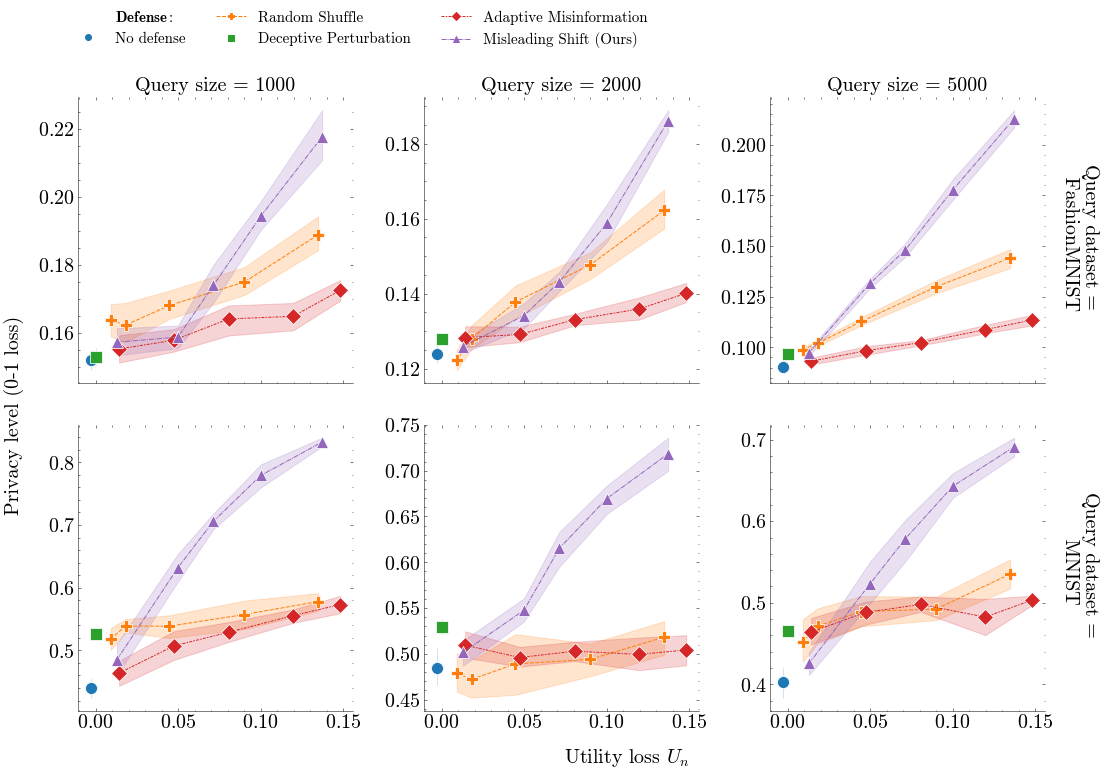

In [20]:
g = sns.relplot(
    data=df, x="un", y="acc", style='defense', markers=markers, legend=True, markersize=12, palette=palette,
    hue="defense", kind='line', col='query size', row='query dataset', facet_kws={'sharey': False, 'sharex': True}
) 

handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    # if not ax.get_subplotspec().is_first_col():
        # ax.set_yticklabels('')
        
handles[0].set_linestyle("")
handles[2].set_linestyle("")
new_handles = [plt.plot([],marker="", ls="")[0]]+handles
new_labels = [r'$\bf{Defense:}$']+labels

# g.set_titles(template = 'query size={col_name}')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['query size'].unique()):
    ax.set_title(f'Query size = {m}')
for ax,l in zip(g.axes[:,0],['FashionMNIST', 'MNIST']):
    ax.set_ylabel('')
for ax,l in zip(g.axes[:,2],['FashionMNIST', 'MNIST']):
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_label_coords(1.2, 0.5)  
    ax.set_ylabel(f'Query dataset = \n {l}', rotation=270, )
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('Privacy level (0-1 loss)')


leg = plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(-0.4, 2.5), ncol=3)
leg._legend_box.align = "left"
leg.get_title().set_position((-2.8, 2.4))
# plt.tight_layout()
plt.savefig('./plots/fmnist_acc_mp.pdf')

In [55]:
df.loc[df['defense']=='No defense', 'un_ce'] = -0.003

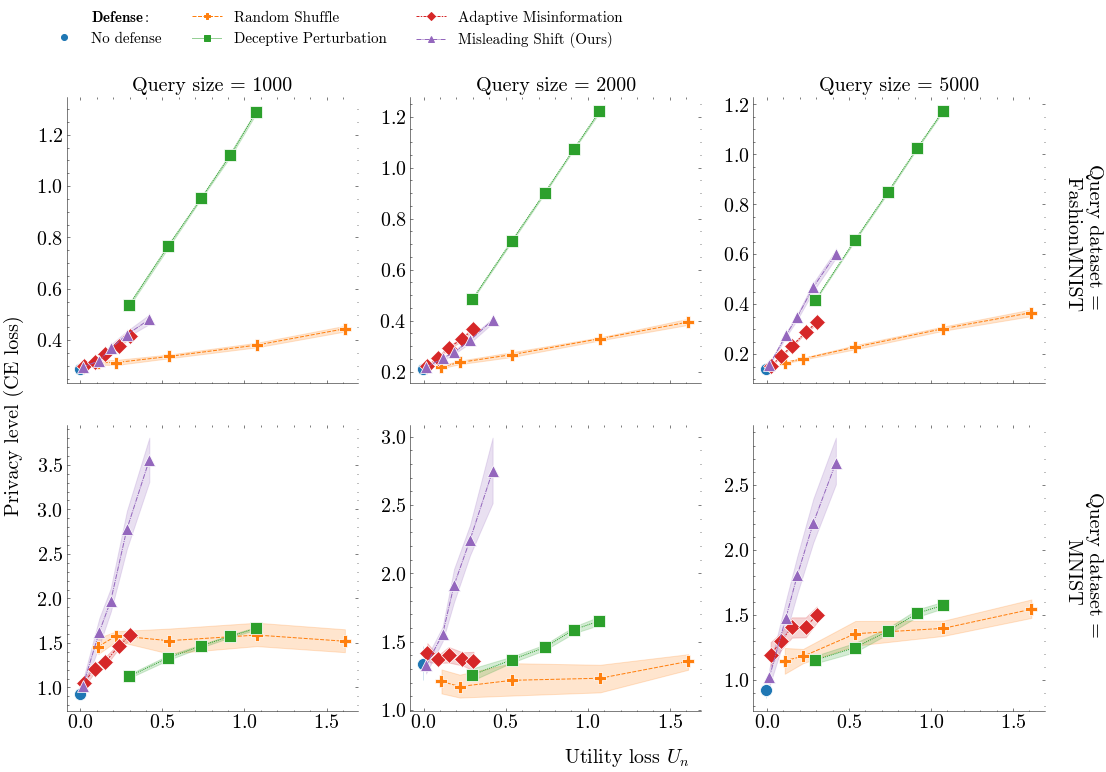

In [21]:
g = sns.relplot(
    data=df, x="un_ce", y="mp_ce", style='defense', markers=markers, markersize=12, legend=True, palette=palette,
    hue="defense", kind='line', col='query size', row='query dataset', facet_kws={'sharey': False, 'sharex': True}
) 

handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    # if not ax.get_subplotspec().is_first_col():
        # ax.set_yticklabels('')
        
handles[0].set_linestyle("")
new_handles = [plt.plot([],marker="", ls="")[0]]+handles
new_labels = [r'$\bf{Defense:}$']+labels

# g.set_titles(template = 'query size={col_name}')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['query size'].unique()):
    ax.set_title(f'Query size = {m}')
for ax,l in zip(g.axes[:,0],['FashionMNIST', 'MNIST']):
    ax.set_ylabel('')
for ax,l in zip(g.axes[:,2],['FashionMNIST', 'MNIST']):
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_label_coords(1.2, 0.5)  
    ax.set_ylabel(f'Query dataset = \n {l}', rotation=270, )
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('Privacy level (CE loss)')

plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(-0.4, 2.5), ncol=3)
# plt.tight_layout()
plt.savefig('./plots/fmnist_ce_mp.pdf')

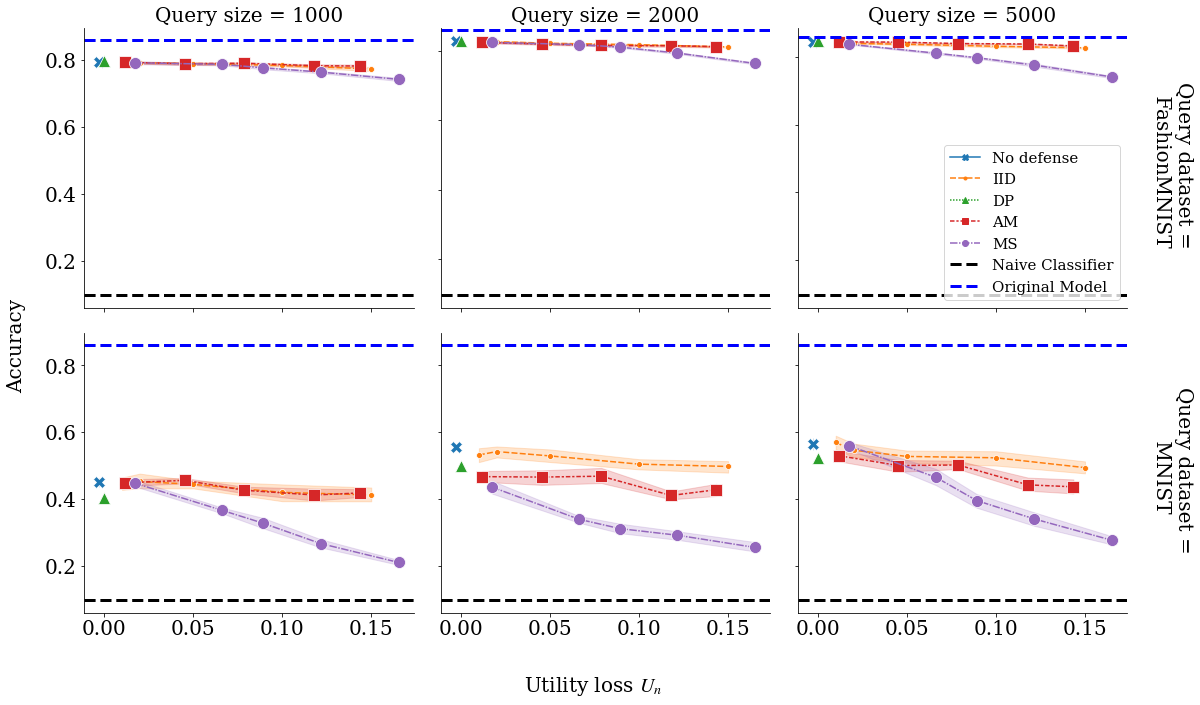

In [226]:
g = sns.relplot(
    data=df, x="un", y="acc", style='defense', markers=markers, markersize=12, legend=True,
    hue="defense", kind='line', col='query size', row='query dataset', facet_kws={'sharey': False, 'sharex': True}
) 

handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)

for ax in g.axes.flatten():
    l1 = ax.axhline(res[0], ls='--', linewidth=3, color='black', label='Naive Classifier')
    l2 = ax.axhline(t_res[0], ls='--', linewidth=3, color='blue', label='Original Model')
    ax.set_xlabel('')
    if not ax.get_subplotspec().is_first_col():
        ax.set_yticklabels('')

new_handles = handles+[l1, l2]
new_labels = labels+['Naive Classifier', 'Original Model']

# g.set_titles(template = 'query size={col_name}')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['query size'].unique()):
    ax.set_title(f'Query size = {m}')
for ax,l in zip(g.axes[:,0],['FashionMNIST', 'MNIST']):
    ax.set_ylabel('')
for ax,l in zip(g.axes[:,2],['FashionMNIST', 'MNIST']):
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_label_coords(1.2, 0.5)  
    ax.set_ylabel(f'Query dataset = \n {l}', rotation=270, )
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('Accuracy')

g.axes[0,-1].legend(new_handles, new_labels, title='', loc = 'lower right')
plt.tight_layout()
plt.savefig('./plots/fmnist_acc.pdf')

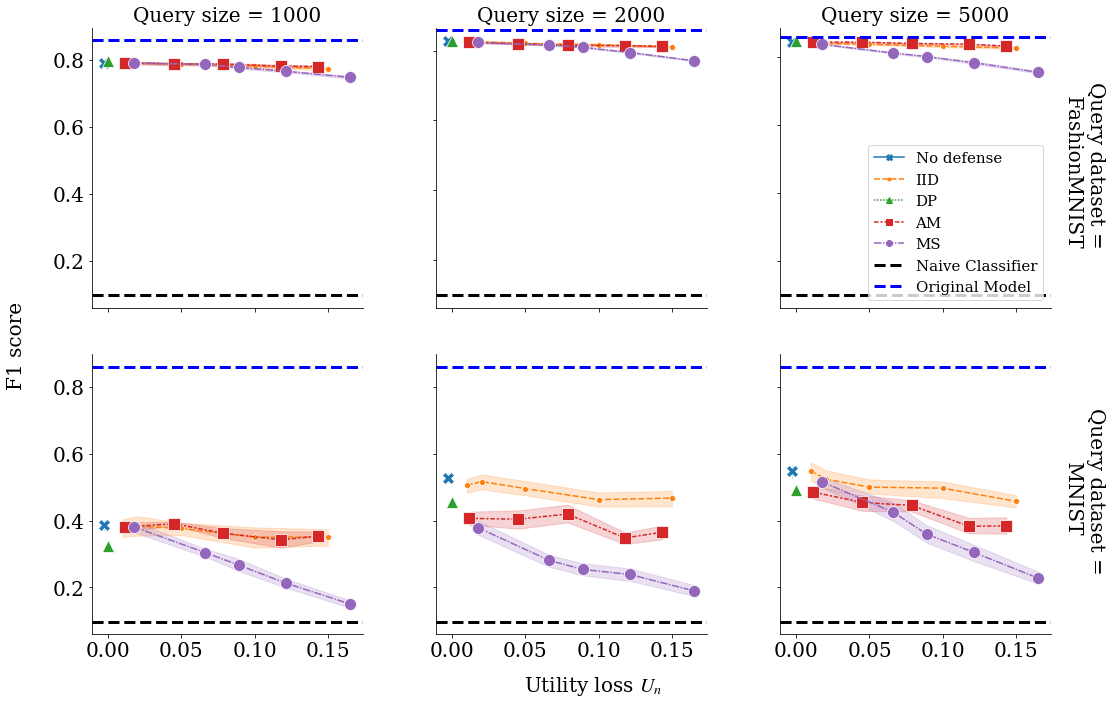

In [227]:
g = sns.relplot(
    data=df, x="un", y="f1", style='defense', markers=markers, markersize=12,
    hue="defense", kind='line', col='query size', row='query dataset', facet_kws={'sharey': False, 'sharex': True}
)
handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)

for ax in g.axes.flatten():
    l1 = ax.axhline(res[1], ls='--', linewidth=3, color='black', label='Naive Classifier')
    l2 = ax.axhline(t_res[1], ls='--', linewidth=3, color='blue', label='Original Model')
    ax.set_xlabel('')
    if not ax.get_subplotspec().is_first_col():
        ax.set_yticklabels('')

new_handles = handles+[l1, l2]
new_labels = labels+['Naive Classifier', 'Original Model']

# g.set_titles(template = 'query size={col_name}')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['query size'].unique()):
    ax.set_title(f'Query size = {m}')
for ax,l in zip(g.axes[:,0],['FashionMNIST', 'MNIST']):
    ax.set_ylabel('')
for ax,l in zip(g.axes[:,2],['FashionMNIST', 'MNIST']):
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_label_coords(1.2, 0.5)  
    ax.set_ylabel(f'Query dataset = \n {l}', rotation=270, )
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('F1 score')

g.axes[0,-1].legend(new_handles, new_labels, title='', loc = 'lower right')
plt.savefig('./plots/fmnist_f1.pdf')